In [130]:
pip install backtrader


Note: you may need to restart the kernel to use updated packages.


In [131]:
import backtrader as bt
import datetime
import yfinance as yf
%matplotlib inline

In [132]:
cerebro=bt.Cerebro() ## cerebro is a class that handels and initiate backtrader library


In [133]:
df=yf.download('AAPL',start='2019-05-05')
import pandas as pd

C:\Users\fardi\AppData\Local\Temp\ipykernel_1812\1979105140.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df=yf.download('AAPL',start='2019-05-05')
[*********************100%***********************]  1 of 1 completed


In [134]:
# تبدیل MultiIndex به ستون ساده
# here columns are in multi index type("AAPLE","Open")

df.columns = df.columns.droplevel('Ticker')
## we delete "APPLE" from the column --> remained ('Open')

df.columns = [col.lower() for col in df.columns]
# this line converts ('Open') -> ('open')

# now we can use the dataframe to our purposes

In [135]:
feed=bt.feeds.PandasData(dataname=df)
#This code converts a pandas DataFrame (df) into a Backtrader data feed for use in trading strategies.

In [136]:
cerebro.adddata(feed)
#adds the data feed (created from the pandas DataFrame) to the Backtrader engine (cerebro) so it can be used in backtesting.

In [137]:
class SmaCross(bt.Strategy):
    # list of parameters which are configurable for the strategy
    params = dict(
        pfast=20,  # period for the fast moving average
        pslow=200   # period for the slow moving average
    )

    def __init__(self):
        sma1 = bt.ind.SMA(period=self.p.pfast)  # fast moving average
        sma2 = bt.ind.SMA(period=self.p.pslow)  # slow moving average
        self.crossover = bt.ind.CrossOver(sma1, sma2)  # crossover signal

    def next(self):
        if not self.position:  # not in the market
            if self.crossover > 0:  # if fast crosses slow to the upside
                self.buy()  # enter long

        elif self.crossover < 0:  # in the market & cross to the downside
            self.close()  # close long position



In [138]:
cerebro.addstrategy(SmaCross)

0

In [139]:
cerebro.addsizer(bt.sizers.PercentSizer,percents=20)

# change default volume of entering the trade
# to 20% of all available money account

In [140]:
cerebro.run()

<IPython.core.display.Javascript object>


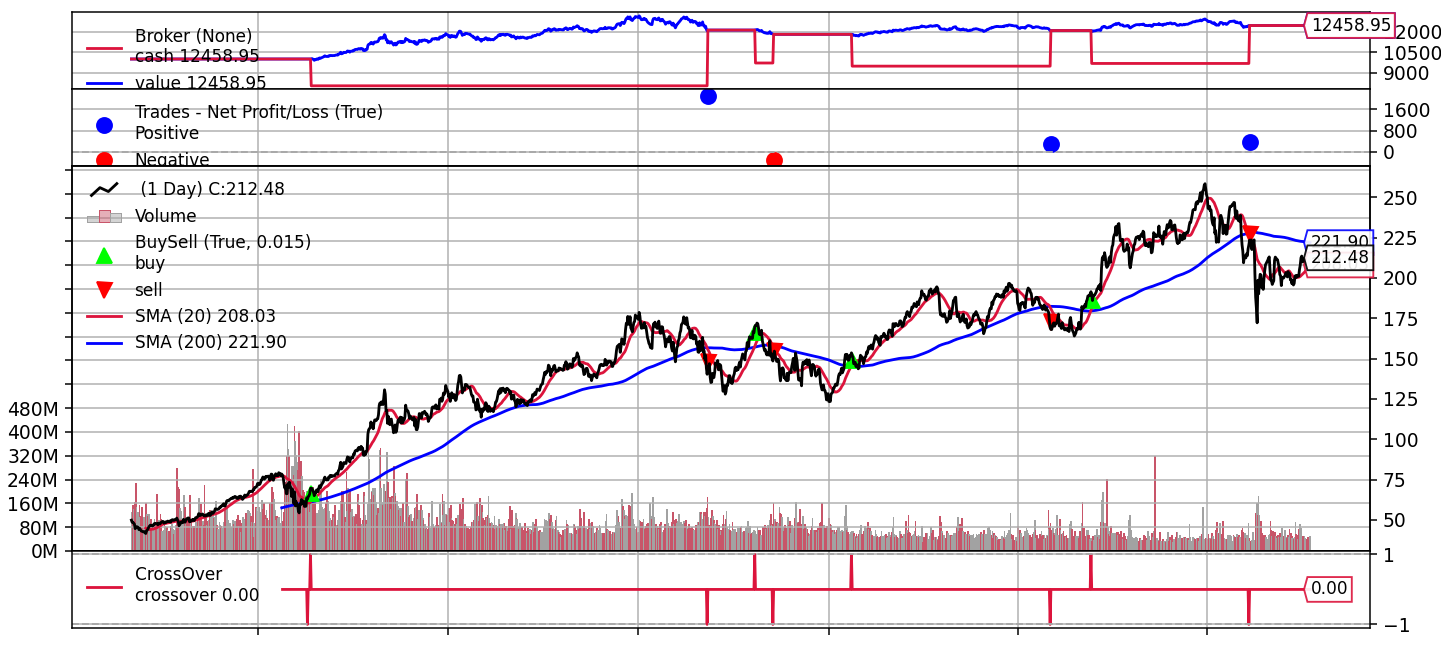

[[<Figure size 432x288 with 5 Axes>]]

In [141]:
cerebro.plot()